## Encoding Numerical Features


### Binning And Binarization

Discretization is the process of transforming continuous variables into discrete
variables by creating a set of contiguous intervals that span the range of the
variable's values. Discretization is also called binning, where bin is an alternative
name for interval.

Why use Discretization:

1. To handle Outliers
2. To improve the value spread

### Three Types are there :-    
1.  Unsupervised - Equal With, Equal Frequency, K-Means  
2. Supervised - Decision Tree Binning  
3. Custom  

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [141]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv', usecols=['Age','Fare','Survived'])

In [142]:
df.dropna(inplace=True)

In [143]:
df.shape

(714, 3)

In [144]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [145]:
x = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [146]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, random_state=42, test_size=0.2
)

In [147]:
y_train.head()

328    1
73     0
253    0
719    0
666    0
Name: Survived, dtype: int64

In [148]:
clf = DecisionTreeClassifier()

clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)
accuracy_score(y_test, y_pred)

0.6223776223776224

In [149]:
np.mean(cross_val_score(DecisionTreeClassifier() , x, y, cv = 10, scoring='accuracy'))

np.float64(0.6232785602503912)

In [150]:
kBin_age = KBinsDiscretizer(n_bins=10, encode='ordinal',strategy='quantile')
kBin_fare = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')

In [151]:
trf = ColumnTransformer([
    ('trf1',kBin_age,[0]),
    ('trf2',kBin_fare,[1])
])

In [152]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

d:\Programming\Machine Learning\7.ToyDataset\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
d:\Programming\Machine Learning\7.ToyDataset\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [153]:
trf.named_transformers_['trf1'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [154]:
trf.named_transformers_['trf2'].n_bins

10

In [155]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'Age_Bin_no':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'Fare_Bin_no':x_train_trf[:,1]
})

In [156]:
output['age_labels'] = pd.cut(x=x_train['Age'],
                                    bins=trf.named_transformers_['trf1'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=x_train['Fare'],
                                    bins=trf.named_transformers_['trf2'].bin_edges_[0].tolist())



In [157]:
output.sample(5)

,age,Age_Bin_no,fare,Fare_Bin_no,age_labels,fare_labels
208,16.0,1.0,7.7500,1.0,"(14.0, 19.0]","(0.0, 7.75]"
571,53.0,9.0,51.4792,8.0,"(50.0, 80.0]","(29.125, 51.479]"
94,59.0,9.0,7.2500,0.0,"(50.0, 80.0]","(0.0, 7.75]"
22,15.0,1.0,8.0292,2.0,"(14.0, 19.0]","(7.896, 9.225]"
505,18.0,1.0,108.9000,9.0,"(14.0, 19.0]","(82.171, 512.329]"


In [158]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred_trf = clf.predict(x_test_trf)

In [159]:
accuracy_score(y_test, y_pred_trf)

0.6223776223776224

In [160]:
np.mean(cross_val_score(DecisionTreeClassifier() , x_train_trf, y_train, cv = 10, scoring='accuracy'))

np.float64(0.6777979431336962)

In [161]:
def discretize(X, y, bins, strategy):

    # -------- transformers ----------
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer([
        ('age', kbin_age, ['Age']),
        ('fare', kbin_fare, ['Fare'])
    ])

    # -------- pipeline for CV ----------
    pipe = Pipeline([
        ('transform', trf),
        ('model', DecisionTreeClassifier())
    ])

    score = np.mean(cross_val_score(pipe, X, y, cv=10, scoring='accuracy'))
    print("CV accuracy:", score)

    # ==================================================
    # ONLY FOR VISUALIZATION (separate fit)
    # ==================================================
    X_trf = trf.fit_transform(X)

    # -------- AGE PLOT ----------
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Age before")

    plt.subplot(122)
    plt.hist(X_trf[:,0])
    plt.title("Age after discretization")

    plt.show()

    # -------- FARE PLOT ----------
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Fare before")

    plt.subplot(122)
    plt.hist(X_trf[:,1])
    plt.title("Fare after discretization")

    plt.show()

CV accuracy: 0.6527190923317684


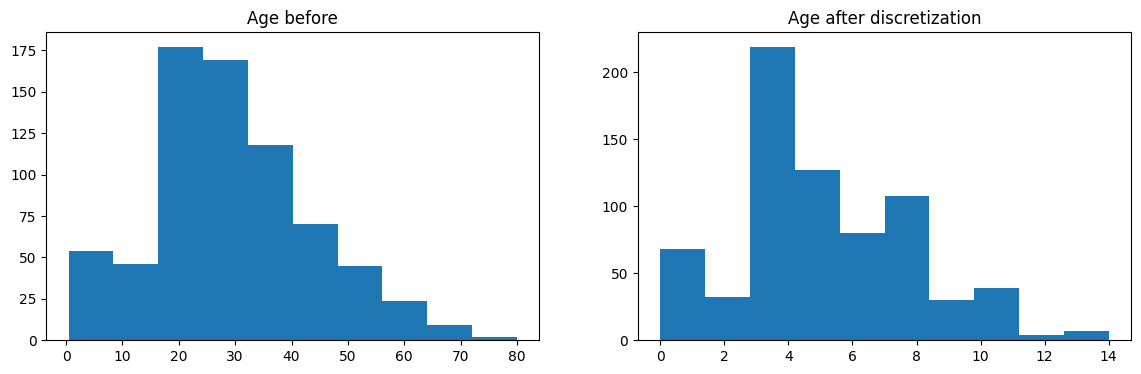

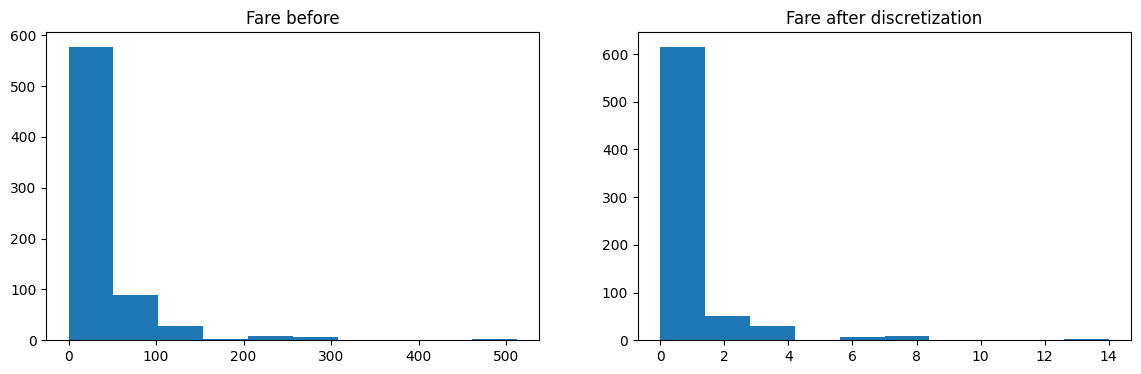

In [166]:
discretize(x,y,15,'uniform')